In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "pyproject.toml").exists())

PARQUET = ROOT / "data" / "criteo_uplift_v2_hashed.parquet"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
RES_DIR = ROOT / "results"

for d in [FIG_DIR, TAB_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    p = FIG_DIR / name
    fig.savefig(p, dpi=110, bbox_inches="tight")
    print("figure saved:", p.name)

def savetab(df_tab, name, index=False):
    p = TAB_DIR / name
    df_tab.to_csv(p, index=index)


In [13]:
FEATS = [f"f{i}" for i in range(12)]
ORIG_COLS = FEATS + ["treatment","conversion","visit","exposure"]
BIN_COLS = ["treatment","conversion","visit","exposure"]


## 1. Loading the data and summary of the schema

In [21]:
df = pd.read_parquet(PARQUET)
print(df.dtypes.to_string())
print("shape:", df.shape)
n_rows, n_cols = df.shape

df.head(3)

f0            float64
f1            float64
f2            float64
f3            float64
f4            float64
f5            float64
f6            float64
f7            float64
f8            float64
f9            float64
f10           float64
f11           float64
treatment       int64
conversion      int64
visit           int64
exposure        int64
row_hash        int64
shape: (13979592, 17)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,row_hash
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,819569959
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,4245558412
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0,2012869148


## 2. Check missing values, impossible values, treatment ratio and outcome rates

In [22]:
miss = pd.DataFrame({"n_missing": df.isna().sum(), "pct_missing": df.isna().mean().values}, index = df.columns)
miss_total = int(miss.n_missing.sum())

if miss_total != 0:
    missed = miss[miss.n_missing > 0]
    print(f"Missing values found in {missed.shape[0]} columns, total missing: {miss_total}")
    print(missed.to_string())
else:
    print("No missing values found.")

miss.T

No missing values found.


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,row_hash
n_missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct_missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
n_inf = int(np.isinf(df[FEATS].to_numpy()).sum()) #check for infinite values in features

feats_min = df[FEATS].min() #minimum values for each feature
feats_max = df[FEATS].max() #maximum values for each feature
below = (df[FEATS] < feats_min).sum().sum() #count of values below minimum (should be 0)
above = (df[FEATS] > feats_max).sum().sum() #count of values above maximum (should be 0)
n_out_of_range = int(below + above) #features outside of range (should be 0)
flag_bad = int(sum((~df[c].isin([0, 1])).sum() for c in BIN_COLS)) #count of binary columns with values other than 0 or 1 (should be 0)

all_pos = flag_bad == 0 and n_out_of_range == 0 and n_inf == 0 
print("IMPOSSIBLE-VALUE SCAN:", "ALL PASS" if all_pos else "PROBLEMS FOUND")

IMPOSSIBLE-VALUE SCAN: ALL PASS


figure saved: treatment_balance.png


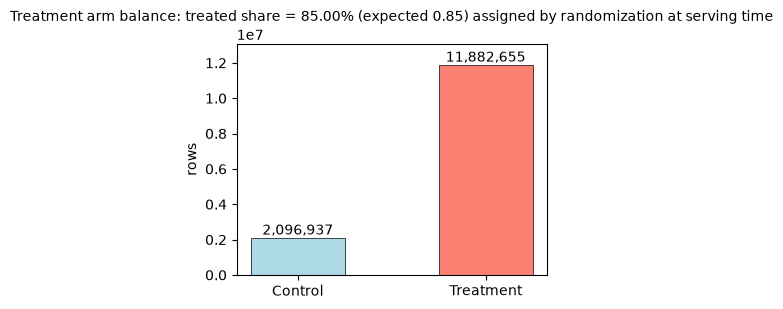

In [23]:
treat_count = df["treatment"].value_counts().sort_index()
n_treat, n_control = int(treat_count[1]), int(treat_count[0])
treated_share = n_treat / (n_treat + n_control)
fig,ax = plt.subplots(figsize=(4,3))
ax.bar([0, 1], [n_control, n_treat], tick_label=['Control', 'Treatment'], color=['lightblue', 'salmon'],
       edgecolor='black', linewidth=0.5, width=0.5)
ax.set_xticks([0,1])
ax.set_xticklabels(['Control', 'Treatment'])
for x, n in zip([0,1], [n_control, n_treat]):
    ax.text(x, n, f"{n:,}", ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, max(n_control, n_treat)*1.1)
ax.set_ylabel("rows")
ax.set_title(f"Treatment arm balance: treated share = {treated_share:.2%} (expected 0.85) assigned by randomization at serving time", fontsize = 10)
savefig(fig, "treatment_balance.png")
plt.show()

Outcome rates by group

visit: control 3.8201% | treated 4.8543% | +1.034 pp | relative +27.1% (ITT)
conversion: control 0.1938% | treated 0.3089% | +0.115 pp | relative +59.4% (ITT)
figure saved: e1_outcome_rates_by_arm.png


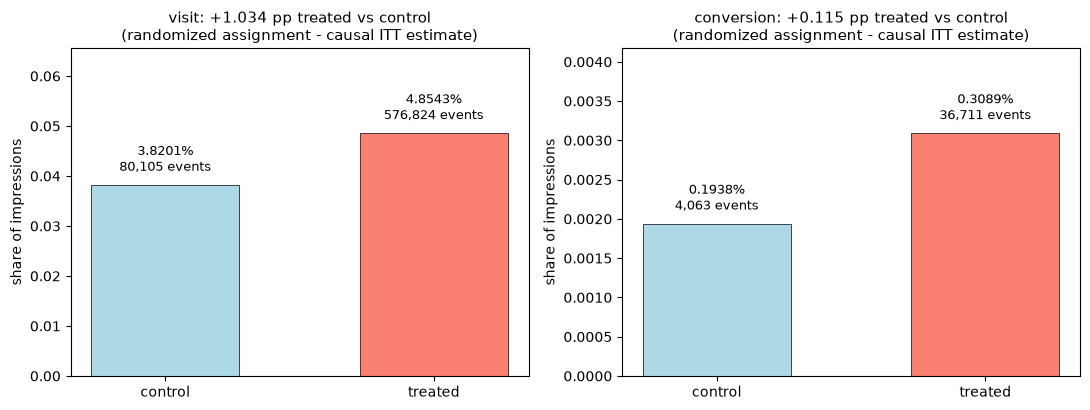

In [24]:
def rate_rows(df, colname):
    g = df.groupby("treatment")[colname].mean()
    c, t = float(g[0]), float(g[1])
    return {"rate_control": c, "rate_treated": t,
            "pp_diff": t - c, "rel_uplift": t / c - 1}

rates = {}
for out in ("visit", "conversion"):
    rates[out] = rate_rows(df, out)
    r = rates[out]
    print(f"{out}: control {r['rate_control']:.4%} | treated {r['rate_treated']:.4%} "
          f"| +{r['pp_diff'] * 100:.3f} pp | relative {r['rel_uplift'] * 100:+.1f}% (ITT)")

visit_pos = df[["visit"]].assign(treatment=df.treatment.values).groupby("treatment")["visit"].sum()
conv_pos  = df[["conversion"]].assign(treatment=df.treatment.values).groupby("treatment")["conversion"].sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, out in zip(axes, ["visit", "conversion"]):
    r = rates[out]
    sums = conv_pos if out == "conversion" else visit_pos
    bars = ax.bar([0, 1], [r["rate_control"], r["rate_treated"]], color=["lightblue", "salmon"], width=0.55, edgecolor="black", linewidth=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["control", "treated"])
    for x, rate, key in zip([0, 1], [r["rate_control"], r["rate_treated"]], [0, 1]):
        label = f"{rate:.4%}\n{int(sums[key]):,} events"
        ax.text(x, rate + r["rate_treated"] * 0.04, label, ha="center", va="bottom", fontsize=9.5)
    ax.set_ylim(0, r["rate_treated"] * 1.35)
    ax.set_ylabel("share of impressions")
    ax.set_title(f"{out}: {(r['rate_treated'] - r['rate_control']) * 100:+.3f} pp treated vs control\n(randomized assignment - causal ITT estimate)", fontsize=10.5)
plt.tight_layout()
savefig(fig, "e1_outcome_rates_by_arm.png")
plt.show()

## 3. Dupplicate analysis
Duplicates are exact matches on the 16 original columns (`f0..f11` + 4 flag columns), i.e. all
content columns;

In [27]:
dup_mask = df.duplicated(subset=ORIG_COLS, keep=False)
grp_order = df.loc[dup_mask, ORIG_COLS].groupby(ORIG_COLS, sort=False).ngroup()
grp_sizes = grp_order.groupby(grp_order).transform("count")



n_dup_rows = int(dup_mask.sum())
n_dup_groups = int(grp_order.nunique())
n_unique_rows = n_rows - int(df.duplicated(subset=ORIG_COLS, keep="first").sum())
print(f"rows in duplicate groups: {n_dup_rows:,} ({n_dup_rows/n_rows:.2%} of total rows)")
print(f"duplicate groups: {n_dup_groups:,} ({n_dup_groups/n_unique_rows:.2%} of unique rows)")
print(f"unique rows without dups: {n_unique_rows:,} ({n_unique_rows/n_rows:.2%} of total rows)")

#How big are duplicate groups? Here we check each row belonging to a group of identical full-row content


extra_counts = np.bincount(grp_sizes.values.astype(int) - 1, minlength=grp_sizes.max())
dup_share_by_arm   = df.assign(_dup=dup_mask.values).groupby("treatment")["_dup"].mean()
dup_share_by_visit = df.assign(_dup=dup_mask.values).groupby("visit")["_dup"].mean()

mult_table = pd.DataFrame({"copies_in_group": np.arange(2, len(extra_counts) + 1),
                           "n_groups": extra_counts[1:].astype(int)})
mult_table["cum_share_groups"] = mult_table.n_groups.cumsum() / mult_table.n_groups.sum()
mult_table["dup_rows"] = mult_table.copies_in_group * mult_table.n_groups
display(mult_table.head(12))


dup_summary = pd.DataFrame({
    "segment": ["overall", "treatment=0 (control)", "treatment=1 (treated)", "visit=0", "visit=1"],
    "n_rows": [n_rows, n_control, n_treat, int((df.visit == 0).sum()), int((df.visit == 1).sum())],
    "dup_rows_involved": [n_dup_rows,
                          int((dup_mask & (df.treatment == 0)).sum()),
                          int((dup_mask & (df.treatment == 1)).sum()),
                          int((dup_mask & (df.visit == 0)).sum()),
                          int((dup_mask & (df.visit == 1)).sum())],
})
dup_summary["dup_share"] = dup_summary.dup_rows_involved / dup_summary.n_rows
dup_summary["delta_vs_overall"] = dup_summary.dup_share - dup_summary.dup_share.iloc[0]
savetab(dup_summary, "e1_duplicates.csv")
dup_summary.round(4)

rows in duplicate groups: 2,221,150 (15.89% of total rows)
duplicate groups: 961,605 (7.56% of unique rows)
unique rows without dups: 12,720,047 (90.99% of total rows)


,copies_in_group,n_groups,cum_share_groups,dup_rows
0,2,1495056,0.673100,2990112
1,3,465027,0.882463,1395081
2,4,166696,0.957513,666784
3,5,60985,0.984969,304925
4,6,21858,0.994810,131148
5,7,7588,0.998226,53116
6,8,2704,0.999444,21632
7,9,837,0.999820,7533
8,10,310,0.999960,3100
9,11,77,0.999995,847


,segment,n_rows,dup_rows_involved,dup_share,delta_vs_overall
0,overall,13979592,2221150,0.1589,0.0000
1,treatment=0 (control),2096937,95221,0.0454,-0.1135
2,treatment=1 (treated),11882655,2125929,0.1789,0.0200
3,visit=0,13322663,2221108,0.1667,0.0078
4,visit=1,656929,42,0.0001,-0.1588


figure saved: e1_duplicate_multiplicity.png


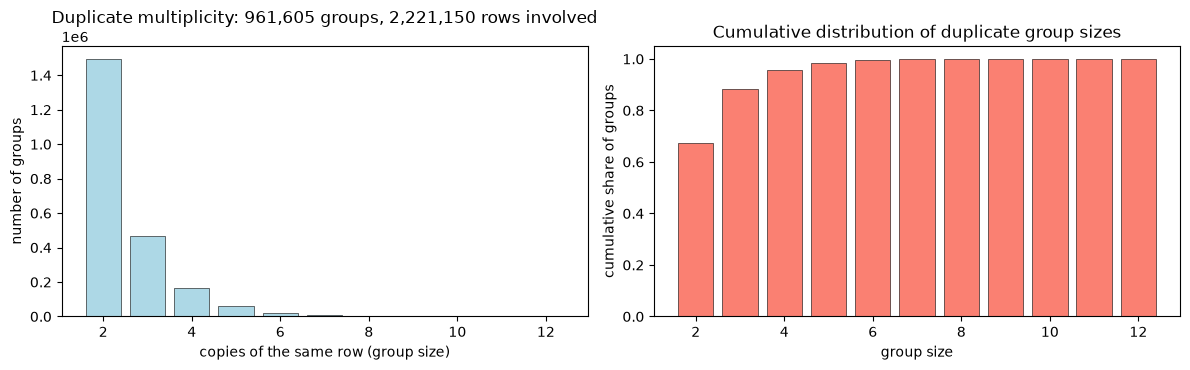

dup share by treatment: control 4.5410% vs treated 17.8910%
dup share by visit    : no-visit 16.6717% vs visit 0.0064%
Large gaps vs overall share imply duplicates were NOT created uniformly at random by arm/outcome.


In [30]:
overall = dup_summary.dup_share.iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sub = mult_table[mult_table.n_groups > 0]
axes[0].bar(sub.copies_in_group, sub.n_groups, color= "lightblue", edgecolor="black", linewidth=0.4)
axes[0].set_xlabel("copies of the same row (group size)")
axes[0].set_ylabel("number of groups")
axes[0].set_title(f"Duplicate multiplicity: {n_dup_groups:,} groups, {n_dup_rows:,} rows involved")
axes[1].bar(sub.copies_in_group, sub.cum_share_groups, color="salmon", edgecolor="black", linewidth=0.4)
axes[1].set_xlabel("group size")
axes[1].set_ylabel("cumulative share of groups")
axes[1].set_title("Cumulative distribution of duplicate group sizes")
plt.tight_layout()
savefig(fig, "e1_duplicate_multiplicity.png")
plt.show()

print(f"dup share by treatment: control {dup_share_by_arm[0]:.4%} vs treated {dup_share_by_arm[1]:.4%}")
print(f"dup share by visit    : no-visit {dup_share_by_visit[0]:.4%} vs visit {dup_share_by_visit[1]:.4%}")
print("Large gaps vs overall share imply duplicates were NOT created uniformly at random by arm/outcome.")

## 4. Feature Analysis

figure saved: e1_feature_distributions.png


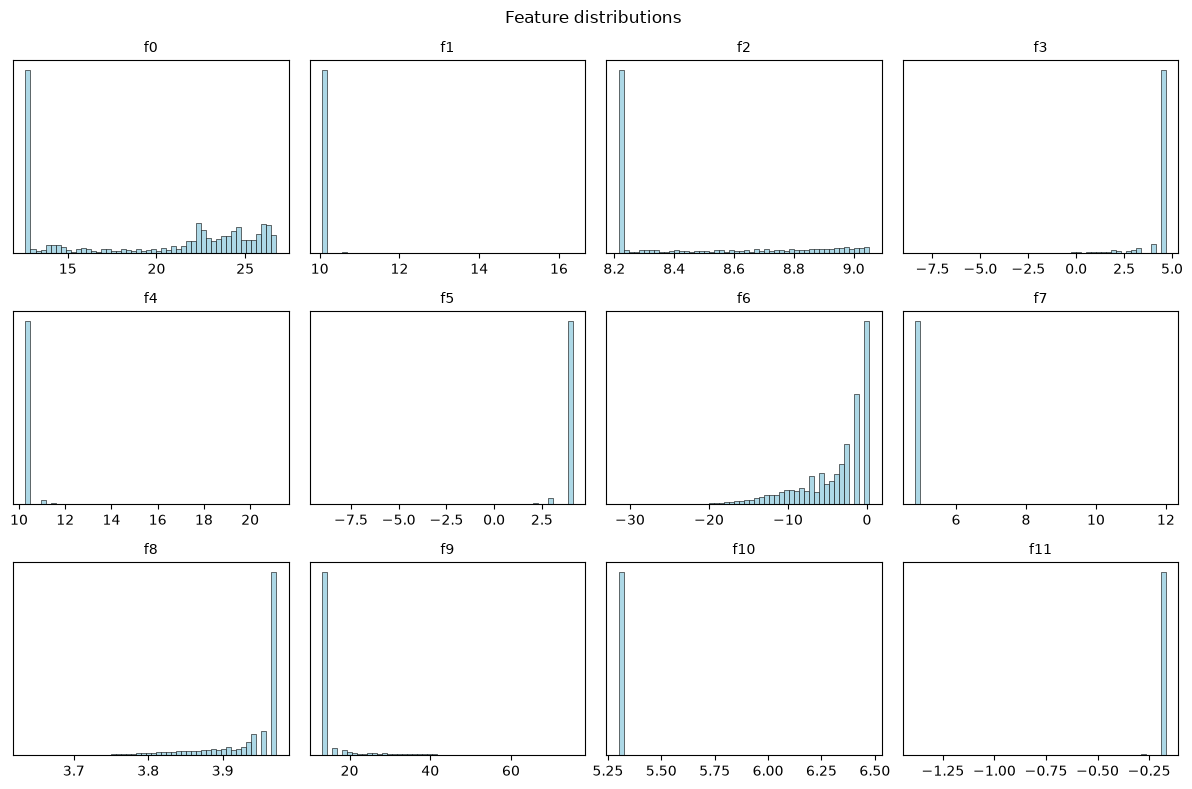

In [32]:
hist_df = df[FEATS]

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, f in zip(axes.ravel(), FEATS):
    v = hist_df[f].to_numpy()
    ax.hist(v, bins=50, color="lightblue", edgecolor="black", linewidth=0.4)
    ax.set_title(f, fontsize=10)
    ax.set_yticks([])

fig.suptitle("Feature distributions", fontsize=12)
plt.tight_layout()
savefig(fig, "e1_feature_distributions.png")
plt.show()


In [ ]:
bounds = []

for f in FEATS: #for each feature, find the min and max values and how many rows have those values
    v = df[f].to_numpy()
    lo, hi = v.min(), v.max()
    n_min, n_max = int(np.sum(v == lo)), int(np.sum(v == hi))

    bounds.append({"feature": f, "min": float(lo), "max": float(hi), "n_min": n_min, "n_max": n_max,
                   "pct_min": n_min / n_rows, "pct_max": n_max / n_rows})

bounds_df = pd.DataFrame(bounds)
bounds_df["min_max_pct"] = bounds_df.pct_min + bounds_df.pct_max #fraction of rows that are at the min or max for each feature

worst = bounds_df.sort_values("min_max_pct", ascending=False).iloc[0]
savetab(bounds_df,"e1_boundary_mass.csv")
bounds_df

,feature,min,max,n_min,n_max,pct_min,pct_max,min_max_pct
0,f0,12.616365,26.745255,3705545,5,2.650682e-01,3.576642e-07,0.265069
1,f1,10.059654,16.344187,13807642,1,9.876999e-01,7.153285e-08,0.987700
2,f2,8.214383,9.051962,7303429,2,5.224351e-01,1.430657e-07,0.522435
3,f3,-8.398387,4.679882,1,11443995,7.153285e-08,8.186215e-01,0.818622
4,f4,10.280525,21.123508,13372695,1,9.565869e-01,7.153285e-08,0.956587
5,f5,-9.011892,4.115453,1,13238149,7.153285e-08,9.469625e-01,0.946963
6,f6,-31.429784,0.294443,1,3705545,7.153285e-08,2.650682e-01,0.265068
7,f7,4.833815,11.998401,13238149,1,9.469625e-01,7.153285e-08,0.946963
8,f8,3.635107,3.971858,3,7303429,2.145985e-07,5.224351e-01,0.522435
9,f9,13.190056,75.295017,11113335,1,7.949685e-01,7.153285e-08,0.794969


Are treated and contol groups similar on the observed feature set? We use Standardized Mean Difference (SMD) to study it. If SMDs are near zero, randomization worked.

In [34]:
X = df[FEATS].to_numpy()
t = df["treatment"].to_numpy()
tmask = t == 1
mt, mc = X[tmask].mean(axis=0), X[~tmask].mean(axis=0)
vt, vc = X[tmask].var(axis=0), X[~tmask].var(axis=0)
pooled_sd = np.sqrt((vt + vc) / 2.0)
smd = (mt - mc) / pooled_sd

t_sd = t.std()
corr_t = ((X - X.mean(axis=0)).T @ (t - t.mean())) / ((n_rows - 1) * pooled_sd * t_sd)

bal = pd.DataFrame({
    "feature": FEATS,
    "mean_treated": mt, "mean_control": mc, "diff": mt - mc,
    "pooled_sd": pooled_sd,
    "SMD": smd, "abs_SMD": np.abs(smd),
    "corr_treatment": corr_t, "abs_corr": np.abs(corr_t),
}).round(6)

order = bal.abs_SMD.sort_values(ascending=False).index
rows = []
for f in ("visit", "conversion", "exposure"):
    g = df.groupby("treatment")[f].mean()
    rows.append({"feature": f, "mean_treated": g[1], "mean_control": g[0],
                 "comment": "daignostic only, not a pre-treatment covariate"})
out_arm = pd.DataFrame(rows).round(6)
savetab(bal, "e1_covariate_balance.csv")
print("Outcome means by arm (informational, not covariates):")
display(out_arm)
bal.sort_values("abs_SMD", ascending=False)

Outcome means by arm (informational, not covariates):


,feature,mean_treated,mean_control,comment
0,visit,0.048543,0.038201,"daignostic only, not a pre-treatment covariate"
1,conversion,0.003089,0.001938,"daignostic only, not a pre-treatment covariate"
2,exposure,0.036037,0.000000,"daignostic only, not a pre-treatment covariate"


,feature,mean_treated,mean_control,diff,pooled_sd,SMD,abs_SMD,corr_treatment,abs_corr
3,f3,4.169412,4.232821,-0.063409,1.298404,-0.048836,0.048836,-0.017438,0.017438
6,f6,-4.182792,-3.999880,-0.182913,4.522160,-0.040448,0.040448,-0.014443,0.014443
5,f5,4.026602,4.039339,-0.012736,0.416808,-0.030557,0.030557,-0.010911,0.010911
9,f9,16.052589,15.886253,0.166336,6.930370,0.024001,0.024001,0.008570,0.008570
1,f1,10.070337,10.067935,0.002401,0.100076,0.023994,0.023994,0.008568,0.008568
8,f8,3.933392,3.934652,-0.001260,0.056162,-0.022433,0.022433,-0.008010,0.008010
7,f7,5.105555,5.080284,0.025271,1.188131,0.021270,0.021270,0.007595,0.007595
10,f10,5.333660,5.331898,0.001762,0.166774,0.010563,0.010563,0.003772,0.003772
4,f4,10.339245,10.336526,0.002720,0.341410,0.007966,0.007966,0.002844,0.002844
0,f0,19.614755,19.651705,-0.036950,5.381841,-0.006866,0.006866,-0.002452,0.002452


figure saved: e1_covariate_balance_smd.png


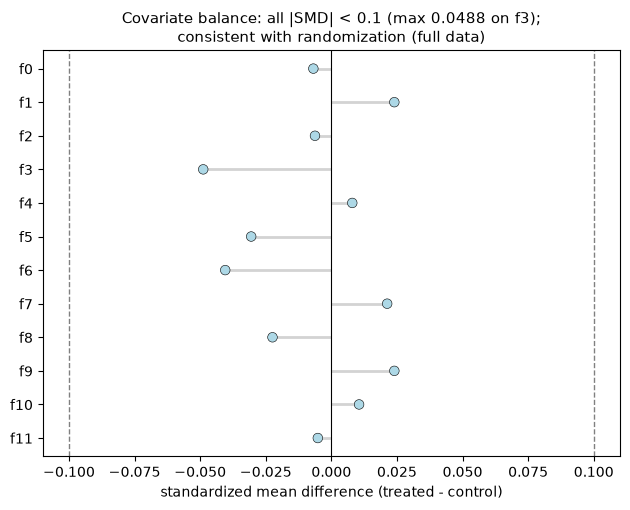

In [37]:
max_smd_f  = bal.loc[bal.abs_SMD.idxmax(), "feature"]
max_corr_f = bal.loc[bal.abs_corr.idxmax(), "feature"]
max_smd_v, max_corr_v = bal.abs_SMD.max(), bal.abs_corr.max()

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ypos = np.arange(len(bal))[::-1]
colors = ["lightblue" if abs(v) < 0.1 else "salmon" for v in bal.SMD]
ax.hlines(ypos, 0, bal.SMD, color="lightgrey", linewidth=2, zorder=1)
ax.scatter(bal.SMD, ypos, c=colors, s=48, zorder=3, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color="grey", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="grey", linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(bal.feature)
ax.set_xlabel("standardized mean difference (treated - control)")
ax.set_title(f"Covariate balance: all |SMD| < 0.1 (max {max_smd_v:.4f} on {max_smd_f});\nconsistent with randomization (full data)", fontsize=11)
plt.tight_layout()
savefig(fig, "e1_covariate_balance_smd.png")
plt.show()

We can quickly check for correlation between features

figure saved: e1_correlation_heatmap.png


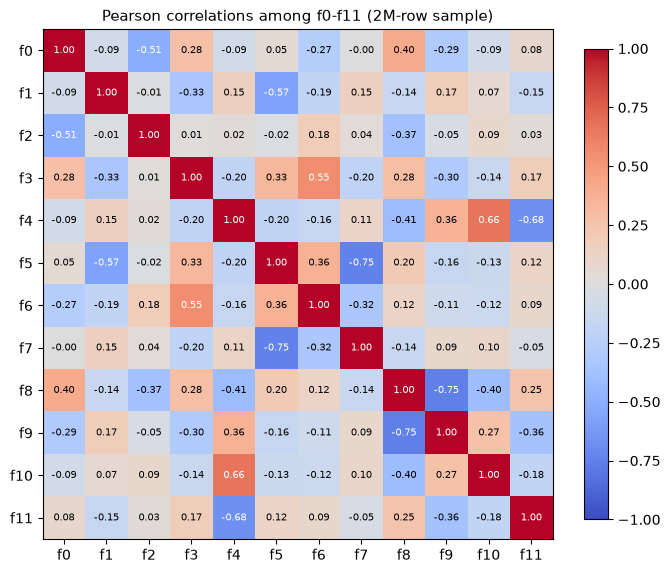

In [39]:
corrM = hist_df.corr()
strong = corrM.abs().mask(np.eye(len(corrM), dtype=bool)).max().max()
n_pairs_strong = int((corrM.abs().where(np.triu(np.ones(corrM.shape), k=1).astype(bool)) > 0.5).sum().sum())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corrM, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(12))
ax.set_xticklabels(FEATS)
ax.set_yticks(range(12))
ax.set_yticklabels(FEATS)
for i in range(12):
    for j in range(12):
        val = corrM.iat[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color="black" if abs(val) < 0.5 else "white")
ax.set_title("Pearson correlations among f0-f11 (2M-row sample)", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
savefig(fig, "e1_correlation_heatmap.png")
plt.show()

## Key takeaways (E1)

- Treatment ratio matches the design (0.850); **covariates show a small but detectable imbalance** as max |SMD| = 0.0488 (f3), which at n≈14M is many standard errors from zero. Consistent with randomization *within each component incrementality test* (the benchmark pools several tests: treatment share varies by position in the file, visit rate by ~3×).
- Treatment worked on both outcomes (ITT): visit up ~1.0 pp, conversion up ~0.1 pp relative to control.
- Duplicates are **not storage artifacts**: the treated arm is ~5.7× larger, and identical feature vectors collide proportionally to group size. Duplicated rows are real users on boundary feature values; the dup share among visitors is ~0.006% simply because visitors sit off the boundary spikes.
- Features are quantile-coded (heavy boundary masses at min/max, typically tens of percent of rows);
- No missing values, no infinities, no out-of-range values, no flag values outside {0,1}.